In [5]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
plt.style.use("mplstyle")

In [8]:
path = 'results'
mode = 'NOFLAG'
# mode = 'PERIODIC'
# mode = 'RANDOM'

inp_signal = '21cm'
# inp_signal = 'FG+21cm'
SCF = 'None'

data = np.load(f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")

kb_dct          = data["kb"]
mean_dct        = data["mean"]
err_dct         = data["err"]
binned_th_dct   = data["binned_th"]

inp_signal      = data["inp_signal"].tolist()
flag            = data["flag"].tolist()
scf             = data["SCF"].tolist()
print(f"inp_signal = {inp_signal}, flag = {flag}, scf = {scf}")

mode = 'PERIODIC+RANDOM'
data = np.load(f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")

kb_fft          = data["kb"]
mean_fft        = data["mean"]
err_fft         = data["err"]
binned_th_fft   = data["binned_th"]

inp_signal1      = data["inp_signal"].tolist()
flag1            = data["flag"].tolist()
scf1             = data["SCF"].tolist()
print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")


inp_signal = 21cm, flag = NOFLAG, scf = None
inp_signal = 21cm, flag = PERIODIC+RANDOM, scf = None


In [15]:
def plot_compare_fft_4flags(
        k_fft_list, mean_fft_list, err_fft_list, binned_th_fft_list,
        flag_labels,
        theory_label=r'${\rm EoR\,Model}$',
        fft_label=r'${\rm Delay\,spectrum\,squared}$',
        fft_dev_label=r'\rm{FFT\ deviation\ (\%)}',
        figsize=(16, 7),
        ylim=None,
        band=True,
        band_alpha=0.15,
        clip_symbol=True,
        verticle=False,
        vline=0.2,
        save=True,
        figname='compare_fft_4flags.pdf'
    ):

    import numpy as np
    import matplotlib.pyplot as plt

    nflag = 4
    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        2, nflag,
        height_ratios=[3, 1],
        hspace=0.07,
        wspace=0.08
    )

    # ---------- helper ----------
    def plot_clipped(ax, k, y, dy, marker, color):
        if ylim is None:
            ax.errorbar(k, y, dy, fmt=marker, capsize=3, color=color)
            return

        mask_in = np.abs(y) <= ylim
        mask_up = y > ylim
        mask_dn = y < -ylim

        if np.any(mask_in):
            line = ax.errorbar(
                k[mask_in], y[mask_in], dy[mask_in],
                fmt=marker, capsize=3, color=color
            )
            c = line[0].get_color()
        else:
            c = color

        if clip_symbol:
            for xi in k[mask_up]:
                ax.text(xi, 0.85 * ylim, r'$\uparrow$',
                        ha='center', va='bottom', color=c)
            for xi in k[mask_dn]:
                ax.text(xi, -0.85 * ylim, r'$\downarrow$',
                        ha='center', va='top', color=c)

    ax_top, ax_dev = [], []

    for i in range(nflag):

        # ================= TOP: Power spectrum =================
        ax1 = fig.add_subplot(gs[0, i])
        ax_top.append(ax1)

        line = ax1.errorbar(
            k_fft_list[i],
            np.abs(mean_fft_list[i]),
            err_fft_list[i],
            fmt='o',
            ls='--',
            label=fft_label
        )
        fft_color = line[0].get_color()

        ax1.plot(
            k_fft_list[i],
            binned_th_fft_list[i],
            '-k',
            lw=2,
            label=theory_label
        )

        ax1.set_yscale('log')
        ax1.set_title(flag_labels[i])
        ax1.grid(alpha=0.3)

        if i == 0:
            ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}^3$')
            ax1.legend(fontsize=9)
        else:
            ax1.tick_params(labelleft=False)

        ax1.tick_params(labelbottom=False)

        if verticle:
            ax1.axvline(vline, ls='--', color='gray')

        # ================= BOTTOM: FFT deviation =================
        ax2 = fig.add_subplot(gs[1, i], sharex=ax1)
        ax_dev.append(ax2)

        ratio_fft = 100 * (mean_fft_list[i] / binned_th_fft_list[i] - 1)
        err_fft_scaled = 100 * err_fft_list[i] / binned_th_fft_list[i]

        plot_clipped(
            ax2,
            k_fft_list[i],
            ratio_fft,
            err_fft_scaled,
            'o',
            fft_color
        )

        if band:
            ax2.fill_between(
                k_fft_list[i],
                -err_fft_scaled,
                err_fft_scaled,
                color=fft_color,
                alpha=band_alpha
            )

        ax2.axhline(0, color='k', ls='--')
        ax2.grid(alpha=0.3)

        if ylim is not None:
            ax2.set_ylim(-ylim, ylim)

        if i == 0:
            ax2.set_ylabel(fft_dev_label)
        else:
            ax2.tick_params(labelleft=False)

        if verticle:
            ax2.axvline(vline, ls='--', color='gray')

        ax2.set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

    fig.align_ylabels()

    if save:
        fig.savefig(figname, bbox_inches='tight')
        print("Saved:", figname)

    return fig, (ax_top, ax_dev)


Saved: plots/dctfft_Data_21cm_SCF_None_Flag_PERIODIC+RANDOM.pdf


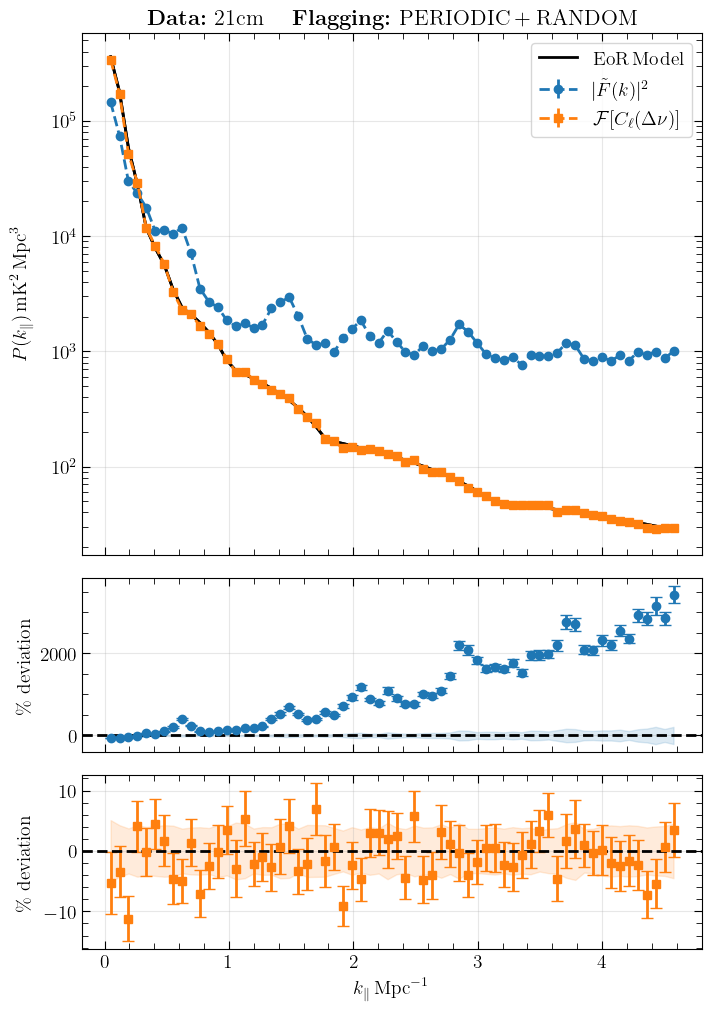

In [14]:

shift = 1.0   # upward shift for clarity
offset_ratio = 0.0  # shift 2 percentage points in ratio plot (optional)
figname = f"plots/dctfft_Data_{inp_signal}_SCF_{SCF}_Flag_{mode}.pdf"  
# figname = f"plots/SCFvNoSCF_Data_{inp_signal}_Flag_{mode}.pdf"  

fig, axes = plts.plot_compare_estimators(
    kb_fft, mean_fft * shift, err_fft*shift, binned_th_fft* shift,
    kb_dct, mean_dct, err_dct, binned_th_dct,
    fft_label=r'$|\tilde{F}(k)|^2$',
    # fft_label=r'${\rm Delay\,spectrum\,squared}$',
    dct_label=r'${ \mathcal{F} [ C_\ell(\Delta\nu) ] }$',
    title = r"\rm{  {\bf Data:}~}" + fr"$\mathrm{{   {inp_signal}   }} \quad$" + r"\rm{ {\bf Flagging:}~"+fr"$\rm{{ {mode} }} $",
    fft_dev_label=r'\rm{\% deviation}',
    dct_dev_label=r'\rm{\% deviation}',
    fft_color='C0', dct_color='C1',
    # title = r"$\bf{{Data:}}$",
    figname=figname,
    # ylim=20
)


inp_signal = 21cm, flag = NOFLAG, scf = None
inp_signal = 21cm, flag = RANDOM, scf = None
inp_signal = 21cm, flag = PERIODIC, scf = None
inp_signal = 21cm, flag = PERIODIC+RANDOM, scf = None
Saved: plots/fft_Data_21cm_SCF_None_allflags.pdf


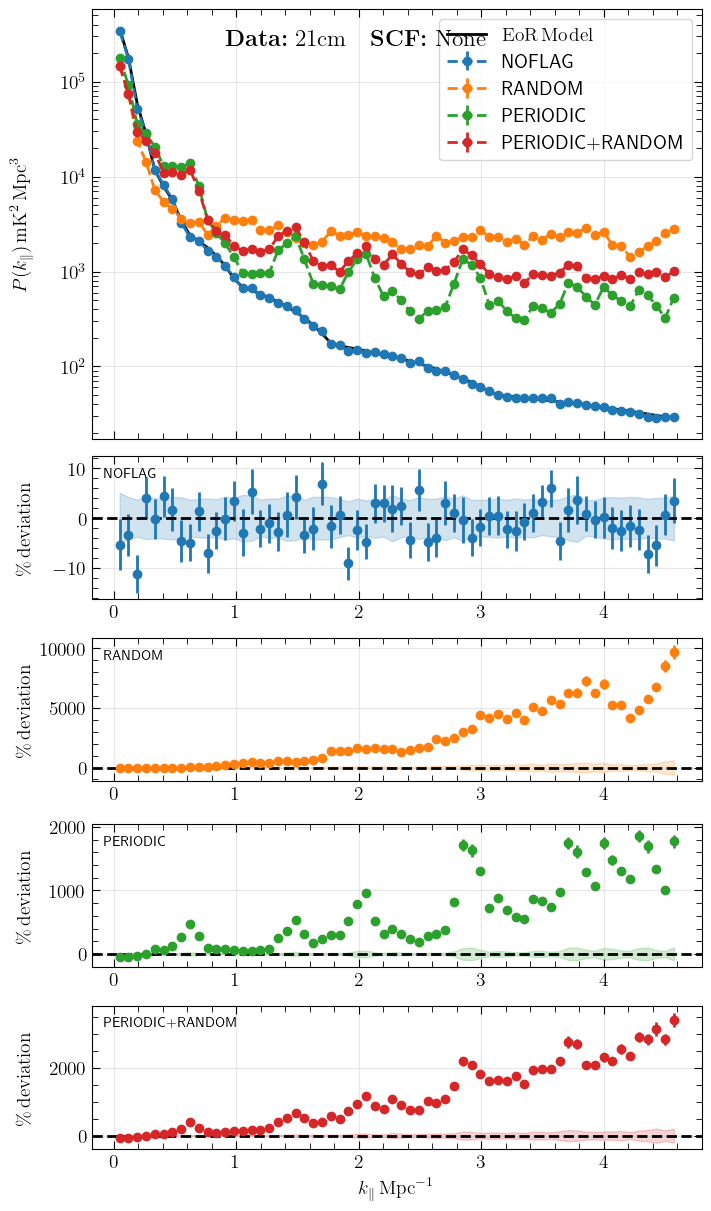

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
path       = "results"
inp_signal = "21cm"
SCF        = "None"

modes  = ['NOFLAG', 'RANDOM', 'PERIODIC', 'PERIODIC+RANDOM']
colors = ['C0', 'C1', 'C2', 'C3']

shift = 1.0
ylim  = None     # set to None if you do not want clipping
band = True

figname = f"plots/fft_Data_{inp_signal}_SCF_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 12))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color) in enumerate(zip(modes, colors)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        mean_fft * shift,
        err_fft * shift,
        fmt='o',
        ls='--',
        color=color,
        label=mode
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        fmt='o',
        color=color
    )

    if band:
        axd[i].fill_between(kb_fft, -err_r, err_r,
                            color=color, alpha=0.2,
                            label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        mode,
        transform=axd[i].transAxes,
        fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)

# --------------------------------------------------
# FINAL FORMATTING
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}^3$')
ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

fig.suptitle(
    r"\rm{{\bf Data:}~}" + fr"$\mathrm{{{inp_signal}}}$"
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\rm{{{SCF}}}$",
    y=0.98
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)
